# **KKBox's Churn Prediction**
KKBOX is Asia’s leading music streaming service, holding the world’s most comprehensive Asia-Pop music library with over 30 million tracks. They offer a generous, unlimited version of their service to millions of people, supported by advertising and paid subscriptions. This delicate model is dependent on accurately predicting churn of their paid users.

In [6]:
# -*- coding: utf-8 -*-
"""PROJECT_1.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1AtFeChBm4W0nxpo6R6U8XDFhAJaDhBvG

# **KKBox's Churn Prediction**
KKBOX is Asia’s leading music streaming service, holding the world’s most comprehensive Asia-Pop music library with over 30 million tracks. They offer a generous, unlimited version of their service to millions of people, supported by advertising and paid subscriptions. This delicate model is dependent on accurately predicting churn of their paid users.

# **DATA CLEANING PHASE**
"""

"PROJECT_1.ipynb\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1AtFeChBm4W0nxpo6R6U8XDFhAJaDhBvG\n\n# **KKBox's Churn Prediction**\nKKBOX is Asia’s leading music streaming service, holding the world’s most comprehensive Asia-Pop music library with over 30 million tracks. They offer a generous, unlimited version of their service to millions of people, supported by advertising and paid subscriptions. This delicate model is dependent on accurately predicting churn of their paid users.\n\n# **DATA CLEANING PHASE**\n"

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import xgboost as xgb
from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter
import sklearn
import shap

In [9]:
# DataFrames Construction
df_transactions = pd.read_csv('/content/data/churn_comp_refresh/transactions_v2.csv')
df_members = pd.read_csv('members_v3.csv')

First, I will explore the datasets to understand the variables, their data types, and begin identifying how to define the time and event features. This is crucial since this dataset will be evaluated as a longitudinal study.

**Let's start by analyzing the Transactions DataFrame**


In [10]:
# Developed a helper function to understand each variable in the DataFrame
def exploratory(df,columna):
  nulos=df[columna].isnull().sum()
  unicos=df[columna].nunique()

  print(f"Data type: {df[columna].dtype}")
  print(f"Null values count: {nulos}")
  print(f"Unique values count: {unicos}")
  print(f"Unique values: {unicos}")

# If the variable is continuous
  if pd.api.types.is_numeric_dtype(df[columna]) and unicos > 20:
    print(df[columna].describe().round(3).to_string())
    print(f"\nSkewness: {df[columna].skew():.2f}")

 # If the variable is categorical or discrete numeric
  if unicos <= 20:
        frecuencias = df[columna].value_counts(dropna=False, normalize=True) * 100
        print(frecuencias.round(2).astype(str) + ' %')

# If the variable is qualitative (categorical text)
  elif pd.api.types.is_object_dtype(df[columna]) or pd.api.types.is_string_dtype(df[columna]):
        print(df[columna].value_counts(dropna=False).head(5))

In [11]:

for column in df_transactions:
  print(f"Variable: {column}")
  exploratory(df_transactions,column)
  print("\n")

Variable: msno
Data type: object
Null values count: 0
Unique values count: 1197050
Unique values: 1197050
msno
72gJqt1O31E/WoxAEYFn9LHNI6mAZFGera5Q6gvsFkA=    208
5ty4nZkq54z93wQtBN7RHVYj8rNghBDCVBH+3xmxf0I=    172
OGKDrZQDB3yewZhoSd5qqvmG5A1GcNTYMexO95NlH+g=    148
WHsCtkOVsauvqBL0ULuG38887y7aU8GXdCmJMjw6hjQ=    145
SNlFRAsmUqnXKPofSXA8WYUc5DtmLcUMy4pXSJ3Ohz0=    131
Name: count, dtype: int64


Variable: payment_method_id
Data type: int64
Null values count: 0
Unique values count: 37
Unique values: 37
count    1431009.000
mean          37.918
std            4.965
min            2.000
25%           36.000
50%           40.000
75%           41.000
max           41.000

Skewness: -2.55


Variable: payment_plan_days
Data type: int64
Null values count: 0
Unique values count: 31
Unique values: 31
count    1431009.000
mean          66.018
std          102.486
min            0.000
25%           30.000
50%           30.000
75%           30.000
max          450.000

Skewness: 2.78


Variable: pl

Now I have complete information about the variables. Although many encodings are anonymized, I observe well-defined, critical variables such as cost, cancellation status, renewal status, transaction dates, subscription start date, and expiration date.

Decisions for the next steps:

*   Convert date columns to DateTime format.
*   `actual_amount_paid` and `plan_list_price` are highly correlated. I will retain `actual_amount_paid` and subtract it from `plan_list_price` to engineer a new variable defining discounts.
*   `is_cancel` will be the target label for the XGBoost-Cox model.
*   Using `transaction_date`, I will establish time 0 as the earliest date.
*   Using `is_cancel`, I will define the actual event of interest.
*   Using `membership_expire_date` and `tenure_days`, I will calculate the time duration to establish the survival analysis framework.




In [12]:
# Convert date variables to DateTime
df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'].astype(str), format='%Y%m%d')
df_transactions['membership_expire_date'] = pd.to_datetime(df_transactions['membership_expire_date'].astype(str), format='%Y%m%d')

In [13]:
# `actual_amount_paid` and `plan_list_price` are very similar. We will keep `actual_amount_paid` and subtract it from `plan_list_price` to engineer a discount variable.
df_transactions['discount'] = df_transactions['plan_list_price'] - df_transactions['actual_amount_paid']
df_transactions=df_transactions.drop("actual_amount_paid",axis=1)

In [14]:
# Check if the new variable was generated correctly
exploratory(df_transactions, "discount")

Data type: int64
Null values count: 0
Unique values count: 27
Unique values: 27
count    1431009.000
mean           0.470
std           14.331
min        -1788.000
25%            0.000
50%            0.000
75%            0.000
max         1599.000

Skewness: -16.57


Mathematically, a negative discount indicates the user paid more than the official price (`actual_amount_paid` > `plan_list_price`). In subscription telemetry, this is almost always noise: late fees, local taxes added to the final charge, or data entry errors in the original database.

In [15]:
# 1. Truncate anomalies: Any value less than 0 becomes 0
df_transactions['discount'] = df_transactions['discount'].clip(lower=0)

# 2. Create a binary variable (1 = Used promotion, 0 = Full fare)
df_transactions['use_discount'] = np.where(df_transactions['discount'] > 0, 1, 0)

# 3. Check the actual percentage of the base retaining a discount
frecuencia_descuento = df_transactions['use_discount'].value_counts(normalize=True) * 100
print("Distribution of users with discount (%):")
print(frecuencia_descuento.round(2))

Distribución de usuarios con descuento (%):
use_discount
0    99.33
1     0.67
Name: proportion, dtype: float64


Now we will prepare the DataFrame to collapse it so that we only have one row per user.




In [16]:
# Examine the remaining variables one by one
# Take the first transaction and the last expiration
# Longitudinal Aggregation (Transactions)
agregaciones_completas = {
    'transaction_date': 'min',
    'membership_expire_date': 'max',
    'is_cancel': 'max',
    'payment_method_id': 'last',
    'is_auto_renew': 'last',
    'payment_plan_days': 'mean',
    # Add our engineered variables:
    'discount': 'mean',             # Historical average discount
    'use_discount': 'last'             # CRITICAL: Was their last renewal promotional?
}

df_survival = df_transactions.groupby('msno').agg(agregaciones_completas).reset_index()

In [17]:
for column in df_survival:
  print(f"Variable: {column}")
  exploratory(df_survival,column)
  print("\n")

Variable: msno
Data type: object
Null values count: 0
Unique values count: 1197050
Unique values: 1197050
msno
zzzF1KsGfHH3qI6qiSNSXC35UXmVKMVFdxkp7xmDMc0=    1
+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=    1
+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=    1
+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=    1
+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=    1
Name: count, dtype: int64


Variable: transaction_date
Data type: datetime64[ns]
Null values count: 0
Unique values count: 815
Unique values: 815


Variable: membership_expire_date
Data type: datetime64[ns]
Null values count: 0
Unique values count: 1229
Unique values: 1229


Variable: is_cancel
Data type: int64
Null values count: 0
Unique values count: 2
Unique values: 2
is_cancel
0    97.11 %
1     2.89 %
Name: proportion, dtype: object


Variable: payment_method_id
Data type: int64
Null values count: 0
Unique values count: 35
Unique values: 35
count    1197050.000
mean          37.835
std            5.000
min            2.000
25%

In [18]:
# Calculate Time (t): Days from the first purchase to the last expiration
df_survival['tenure_days'] = (df_survival['membership_expire_date'] - df_survival['transaction_date']).dt.days


In [19]:
# In survival analysis, follow-up time must always be greater than 0
# We remove any reversed date errors or zero-day durations.
df_survival = df_survival[df_survival['tenure_days'] > 0]

# Inspect the fundamental new variable
exploratory(df_survival, 'tenure_days')

Data type: int64
Null values count: 0
Unique values count: 1813
Unique values: 1813
count    1188710.000
mean          84.799
std          137.252
min            1.000
25%           30.000
50%           31.000
75%           41.000
max         7335.000

Skewness: 4.27


In [20]:
# There are extremely high values corresponding to 20-year subscriptions, which is anomalous. We will remove these outliers.
# Outlier Filter: Remove system errors (> 10 years)
limite_dias = 3650
df_survival = df_survival[df_survival['tenure_days'] <= limite_dias]
exploratory(df_survival, 'tenure_days')

Data type: int64
Null values count: 0
Unique values count: 1807
Unique values: 1807
count    1188704.000
mean          84.777
std          136.852
min            1.000
25%           30.000
50%           31.000
75%           41.000
max         3290.000

Skewness: 4.08


NOW THAT OUR FIRST DATABASE IS CLEANED AND WE HAVE DEFINED OUR TIME AND EVENT (SUBSCRIPTION CANCELLATION), WE CAN PROCEED TO ANALYZE THE MEMBERS_V3 DATABASE

In [21]:
for column in df_members:
  print(f"Variable: {column}")
  exploratory(df_members,column)
  print("\n")

Variable: msno
Data type: object
Null values count: 0
Unique values count: 6769473
Unique values: 6769473
msno
isBt+JlgvZRNy6lxVr5vvuJ4lD00ofTaKyJ+uRnGcPg=    1
O17RLjJp7AVhS1G1TJ8LjZHoIeoeGi1jwlV3kIth47Q=    1
IwDZCuhB0UP7wrBwuqE1r1jQIA0yFSTqUGlGJnM+hMI=    1
wv7xKoYMhXk+UT6x6GDrXC3aJ7O5RPWXZhSkS9TfLl0=    1
WDGMzy3arZrbDZWAd/BaWTKmILEF9N2zHRN2gfciPKY=    1
Name: count, dtype: int64


Variable: city
Data type: int64
Null values count: 0
Unique values count: 21
Unique values: 21
count    6769473.000
mean           3.847
std            5.478
min            1.000
25%            1.000
50%            1.000
75%            4.000
max           22.000

Skewness: 1.96


Variable: bd
Data type: int64
Null values count: 0
Unique values count: 386
Unique values: 386
count    6769473.000
mean           9.796
std           17.926
min        -7168.000
25%            0.000
50%            0.000
75%           21.000
max         2016.000

Skewness: -30.78


Variable: gender
Data type: object
Null values 

In [22]:
# Convert to text and then to datetime using the year-month-day format
df_members['registration_init_time'] = pd.to_datetime(df_members['registration_init_time'].astype(str), format='%Y%m%d', errors='coerce')

In [23]:
# For implausible ages observed in 'bd', we will replace them with NaNs
df_members['bd'] = np.where(
    (df_members['bd'] >= 14) & (df_members['bd'] <= 90),
    df_members['bd'],
    np.nan
)

In [24]:
# Since there are too many missing genders to impute, we will generate a new risk profile for those who withheld this information and encode them
df_members['gender'] = df_members['gender'].fillna('Unknown')
mapeo_genero = {
    'Unknown': 2,
    'female': 0,
    'male': 1
}

# Apply the mapping to the column
df_members['gender'] = df_members['gender'].map(mapeo_genero)
print(df_members['gender'].value_counts(dropna=False))

gender
2    4429505
1    1195355
0    1144613
Name: count, dtype: int64


In [25]:
# Convert numeric codes to text to prevent them from being treated as continuous variables
df_members['city'] = df_members['city'].astype(str)
df_members['registered_via'] = df_members['registered_via'].astype(str)

In [26]:
for column in df_members:
  print(f"Variable: {column}")
  exploratory(df_members,column)
  print("\n")

Variable: msno
Data type: object
Null values count: 0
Unique values count: 6769473
Unique values: 6769473
msno
isBt+JlgvZRNy6lxVr5vvuJ4lD00ofTaKyJ+uRnGcPg=    1
O17RLjJp7AVhS1G1TJ8LjZHoIeoeGi1jwlV3kIth47Q=    1
IwDZCuhB0UP7wrBwuqE1r1jQIA0yFSTqUGlGJnM+hMI=    1
wv7xKoYMhXk+UT6x6GDrXC3aJ7O5RPWXZhSkS9TfLl0=    1
WDGMzy3arZrbDZWAd/BaWTKmILEF9N2zHRN2gfciPKY=    1
Name: count, dtype: int64


Variable: city
Data type: object
Null values count: 0
Unique values count: 21
Unique values: 21
city
1     4804326
5      385069
13     320978
4      246848
22     210407
Name: count, dtype: int64


Variable: bd
Data type: float64
Null values count: 4550300
Unique values count: 77
Unique values: 77
count    2219173.000
mean          29.437
std           10.311
min           14.000
25%           22.000
50%           27.000
75%           35.000
max           90.000

Skewness: 1.13


Variable: gender
Data type: int64
Null values count: 0
Unique values count: 3
Unique values: 3
gender
2    65.43 %
1    17.66

**Now that both databases are ready, we can perform the merge for descriptive analysis**

In [27]:
# Merge the transactional table with the demographic table using the user ID
df_master = pd.merge(df_survival, df_members, on='msno', how='left')

In [28]:
# Evaluate the merge
filas_antes = df_survival.shape[0]
filas_despues = df_master.shape[0]

print(f"Subjects in the original cohort (df_survival): {filas_antes:,}")
print(f"Subjects after the merge (df_master):{filas_despues:,}")

# If a transaction 'msno' did not exist in the members table,
# Pandas will fill its demographic columns (like 'city') with NaN.
usuarios_sin_perfil = df_master['city'].isnull().sum()

print(f"Users with no demographic record found: {usuarios_sin_perfil}")


Subjects in the original cohort (df_survival): 1,188,704
Subjects after the merge (df_master):1,188,704
Users with no demographic record found: 117982


In [29]:
# Fill categorical variables with an explicit class
columnas_categoricas = ['city', 'registered_via', 'gender']
df_master[columnas_categoricas] = df_master[columnas_categoricas].fillna('Unknown')

# Quick verification
nulos_ciudad = df_master['city'].isnull().sum()
print(f"Remaining nulls in 'city' (Categorical): {nulos_ciudad}")

Remaining nulls in 'city' (Categorical): 0


In [30]:
# Since we have `registration_init_time` along with `transaction_date`, we can engineer a new variable indicating the time
# elapsed from app discovery to premium conversion (payment).
df_master['dias_desde_registro'] = (df_master['transaction_date'] - df_master['registration_init_time']).dt.days
# If there are inconsistent registration dates (e.g., purchased before system registration), truncate to 0
df_master['dias_desde_registro'] = df_master['dias_desde_registro'].clip(lower=0)

In [31]:
# Drop date columns (XGBoost does not process timestamps) and keep only the calculated days
columnas_temporales = ['transaction_date', 'membership_expire_date', 'registration_init_time']
df_master = df_master.drop(columns=columnas_temporales)

In [32]:
df_master.to_csv('df_master.csv', index=False)

# **One-Hot Encoding**

In [33]:
columnas_categoricas = ['city', 'registered_via', 'payment_method_id', 'gender']

for col in columnas_categoricas:
    df_master[col] = df_master[col].astype(str)

print("Applying One-Hot Encoding (Dummy variables creation)...")
# pd.get_dummies automatically converts text categories into binary columns
df_master_encoded = pd.get_dummies(df_master, columns=columnas_categoricas)

print(f"Columns before: {df_master.shape[1]}")
print(f"Columns now (expanded matrix): {df_master_encoded.shape[1]}")

2. Applying One-Hot Encoding (Dummy variables creation)...
Columns before: 13
Columns now (expanded matrix): 76


# **Exploratory Data Analysis (EDA)**

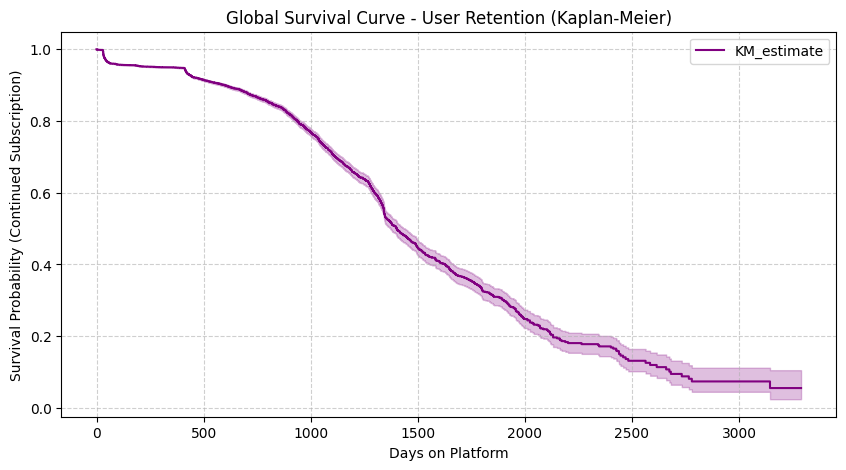


Median survival time: 1402.0 days


In [34]:
kmf = KaplanMeierFitter()
# Fit with lifespan days (duration) and the churn event
kmf.fit(durations=df_master_encoded['tenure_days'], event_observed=df_master_encoded['is_cancel'])
plt.figure(figsize=(10, 5))
kmf.plot_survival_function(color='purple', ci_show=True)

plt.title('Global Survival Curve - User Retention (Kaplan-Meier)')
plt.xlabel('Days on Platform')
plt.ylabel('Survival Probability (Continued Subscription)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Imprimir la probabilidad estimada a los 30 y 365 días (muy útil para el reporte)
med_survival = kmf.median_survival_time_
print(f"\nMedian survival time: {med_survival} days")

/tmp/ipykernel_4491/2549335950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


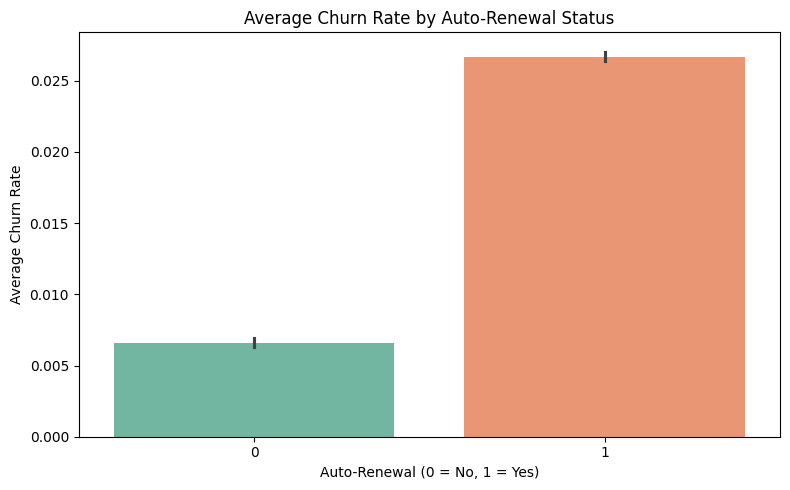

In [35]:
plt.figure(figsize=(8, 5))

# Use a direct variable from the wide DataFrame
sns.barplot(
    data=df_master_encoded,
    x='is_auto_renew',
    y='is_cancel',
    errorbar='ci',
    palette='Set2'
)

plt.title('Average Churn Rate by Auto-Renewal Status')
plt.xlabel('Auto-Renewal (0 = No, 1 = Yes)')
plt.ylabel('Average Churn Rate')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4491/3481255485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tasas, x='Tasa_Churn', y='Metodo', palette='mako')


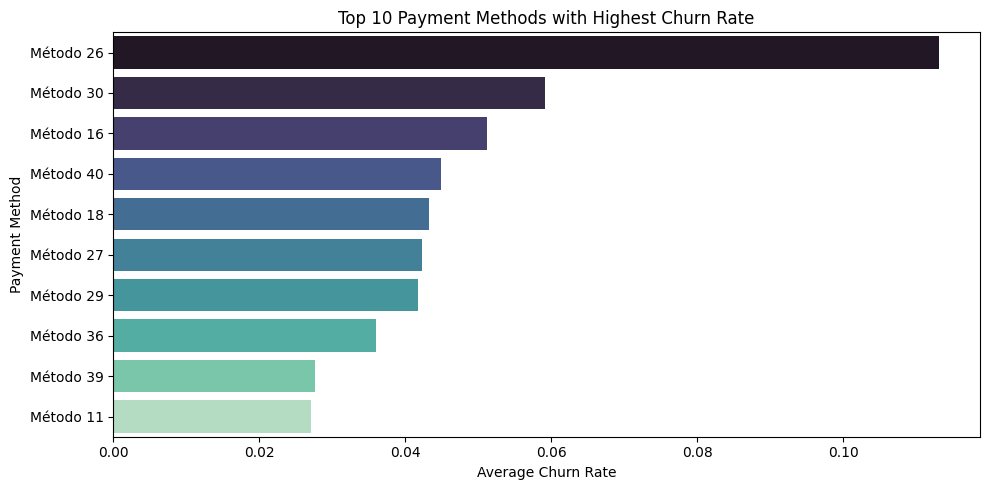

In [36]:
cols_pago = [col for col in df_master_encoded.columns if col.startswith('payment_method_id_')]
tasas_pago = {}
for col in cols_pago:
    # The mean of a binary column (0 and 1) provides the exact proportion rate
    tasa = df_master_encoded[df_master_encoded[col] == 1]['is_cancel'].mean()
    # Clean the name for better label visualization (removing the prefix)
    nombre_metodo = col.replace('payment_method_id_', 'Método ')
    tasas_pago[nombre_metodo] = tasa

# Convert to a temporary DataFrame for easy plotting with Seaborn
df_tasas = pd.DataFrame(list(tasas_pago.items()), columns=['Metodo', 'Tasa_Churn'])
df_tasas = df_tasas.sort_values(by='Tasa_Churn', ascending=False).head(10) # Top 10

# Generate the horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df_tasas, x='Tasa_Churn', y='Metodo', palette='mako')

plt.title('Top 10 Payment Methods with Highest Churn Rate')
plt.xlabel('Average Churn Rate')
plt.ylabel('Payment Method')

plt.tight_layout()
plt.show()

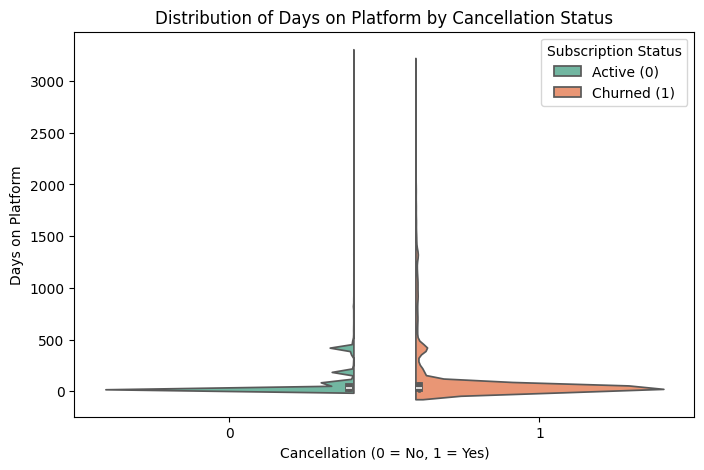

In [37]:
plt.figure(figsize=(8, 5))
ax=sns.violinplot(data=df_master_encoded,
               x="is_cancel",
               y="tenure_days",
               hue="is_cancel",
               split=True,
               palette="Set2"
               )
legend = ax.legend(title="Subscription Status", loc="upper right")
new_labels = ['Active (0)', 'Churned (1)']
for t, l in zip(legend.texts, new_labels):
    t.set_text(l)
plt.xlabel("Cancellation (0 = No, 1 = Yes)")
plt.ylabel("Days on Platform")
plt.title("Distribution of Days on Platform by Cancellation Status")
plt.show()

# **Modeling and Evaluation**

PERFORMING DATA PREPARATION FOR THE MODEL

We opted to preserve data sparsity through informative missingness indicators, leveraging XGBoost's sparsity-aware architecture to mitigate memory biases.


In [38]:
df_modelo = df_master_encoded.set_index('msno')

df_modelo['bd_is_missing'] = df_modelo['bd'].isnull().astype(int)
df_modelo['dias_missing'] = df_modelo['dias_desde_registro'].isnull().astype(int)

X = df_modelo.drop(columns=['tenure_days', 'is_cancel'])
y_cox = np.where(df_modelo['is_cancel'] == 1,
                 df_modelo['tenure_days'],
                 -df_modelo['tenure_days'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cox,
    test_size=0.2,
    random_state=42
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_test, label=y_test)

print(f"Training Set: {dtrain.num_row():,} users")
print(f"Test Set: {dval.num_row():,} users")

Training Set: 950,963 users
Test Set: 237,741 users


In [39]:
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'max_depth': 5,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist'
}

# Configure internal cross-validation during training
evallist = [(dval, 'eval'), (dtrain, 'train')]
num_round = 50

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_round,
    evals=evallist
)


[0]	eval-cox-nloglik:11.03361	train-cox-nloglik:12.40089
[1]	eval-cox-nloglik:10.87665	train-cox-nloglik:12.24528
[2]	eval-cox-nloglik:10.80133	train-cox-nloglik:12.16872
[3]	eval-cox-nloglik:10.73611	train-cox-nloglik:12.10305
[4]	eval-cox-nloglik:10.66909	train-cox-nloglik:12.03467
[5]	eval-cox-nloglik:10.62154	train-cox-nloglik:11.98659
[6]	eval-cox-nloglik:10.57961	train-cox-nloglik:11.94494
[7]	eval-cox-nloglik:10.52229	train-cox-nloglik:11.88924
[8]	eval-cox-nloglik:10.48928	train-cox-nloglik:11.85513
[9]	eval-cox-nloglik:10.46073	train-cox-nloglik:11.82599
[10]	eval-cox-nloglik:10.43998	train-cox-nloglik:11.80456
[11]	eval-cox-nloglik:10.41971	train-cox-nloglik:11.78366
[12]	eval-cox-nloglik:10.39215	train-cox-nloglik:11.75475
[13]	eval-cox-nloglik:10.37525	train-cox-nloglik:11.73741
[14]	eval-cox-nloglik:10.35770	train-cox-nloglik:11.71953
[15]	eval-cox-nloglik:10.34268	train-cox-nloglik:11.70420
[16]	eval-cox-nloglik:10.33009	train-cox-nloglik:11.69133
[17]	eval-cox-nloglik:10

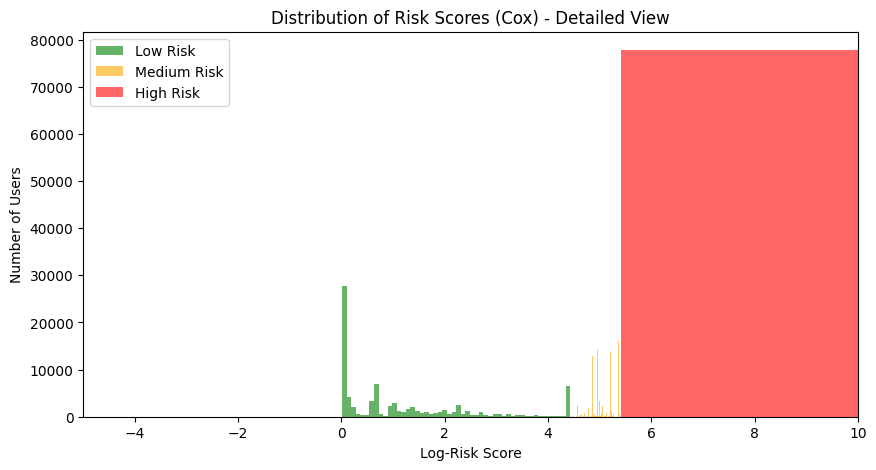

In [48]:

scores_risk = bst.predict(dval)
risk_categories = pd.qcut(scores_risk, q=3, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(10, 5))
plt.hist(scores_risk[risk_categories == 'Low'], bins=50, alpha=0.6, color='green', label='Low Risk')
plt.hist(scores_risk[risk_categories == 'Medium'], bins=50, alpha=0.6, color='orange', label='Medium Risk')
plt.hist(scores_risk[risk_categories == 'High'], bins=50, alpha=0.6, color='red', label='High Risk')

plt.title('Distribution of Risk Scores (Cox) - Detailed View')
plt.xlabel('Log-Risk Score')
plt.ylabel('Number of Users')
plt.xlim(-5, 10)  # Zoom to prevent extreme values from flattening the plot
plt.legend()
plt.show()


Generando gráfica de importancia de variables...


<Figure size 1000x600 with 0 Axes>

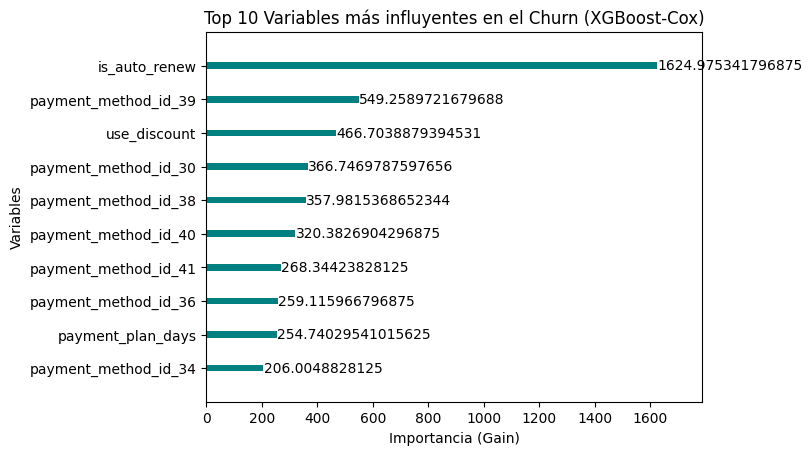

In [41]:
# Let's discover which variables drive cancellation
plt.figure(figsize=(10, 6))

# Plot feature gain or weight
xgb.plot_importance(
    bst,
    max_num_features=10,
    importance_type='gain', # 'gain' measures how much a feature improves loss reduction
    color='teal',
    grid=False
)

plt.title('Top 10 Most Influential Variables on Churn (XGBoost-Cox)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Variables')
plt.show()

In [42]:
explainer_xgb = shap.Explainer(bst)
shap_values_xgb = explainer_xgb(X_test)

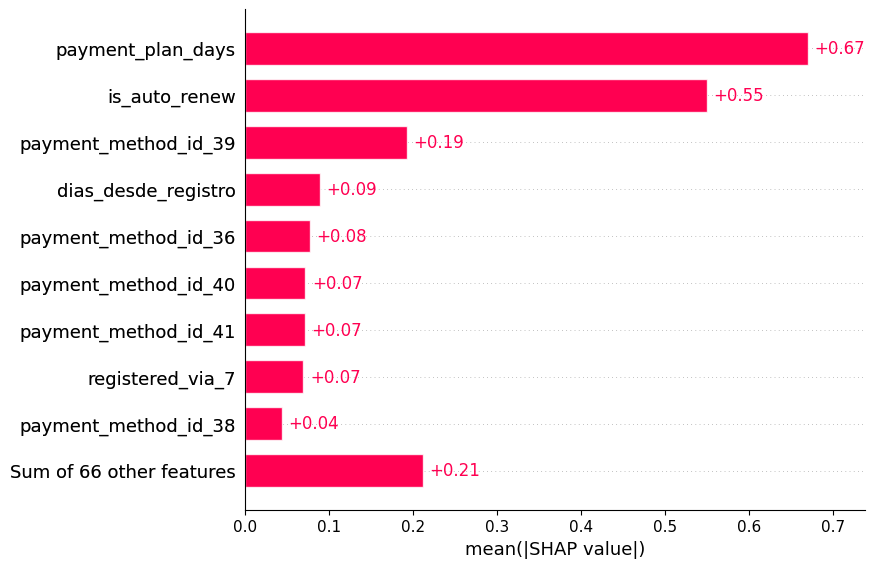

In [43]:
shap.plots.bar(shap_values_xgb)

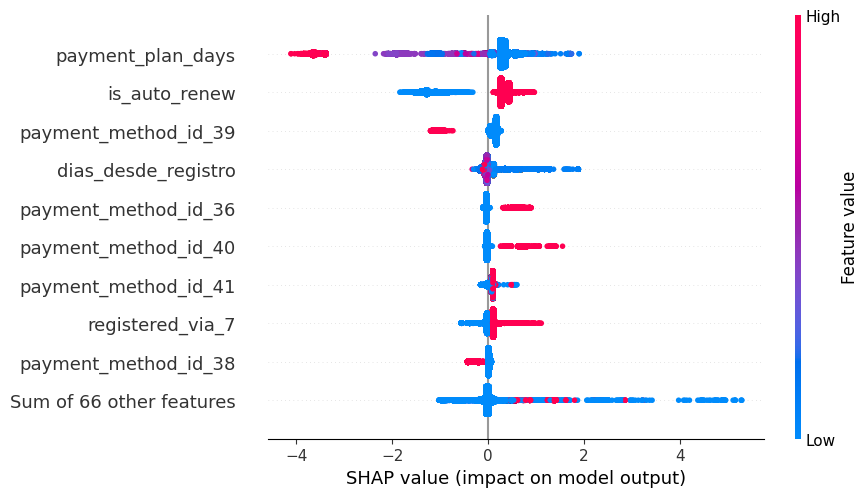

In [44]:
shap.plots.beeswarm(shap_values_xgb)

Users purchasing short-term plans (monthly or weekly subscriptions) exhibit lower drastic churn inertia because they consciously or flexibly renew month-to-month.

However, rigid long-term plans generate initial commitment friction. **Marketing Strategy:** Design retention incentives right before the end of the first month's cycle and evaluate if quarterly or annual plans require a more aggressive "onboarding" campaign to mitigate the renewal shock.

Auto-renewal exposes the model to the financial "moment of truth": declined cards, insufficient funds, or the visibility of recurring charges trigger immediate formal cancellations upon the billing attempt. **Financial Strategy:** Implement an intelligent "smart retries" payment system and preventive email notifications before the automatic charge hits the user's card to avoid friction-based drop-offs.

Not all payment gateways or local methods retain clients equally. Certain methods (like cash payments at convenience stores or high-friction banking gateways) force the user to renew manually every time, elevating both passive and active churn. **Commercial Strategy:** Promote the migration of users from these methods to native gateways or secure direct debit cards, offering a one-time discount on their next invoice if they switch to a low-risk payment method.

The variable `dias_desde_registro` (days since registration) demonstrates that cancellation risk is not linear; there is a critical maturity point where, if the user was not offered relevant musical content (recalling that KKBox is music streaming), platform fatigue risk skyrockets as days pass since initial registration.

